In [1]:
import os 
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers,models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns


In [2]:
dataset_path="Dataset"


IMAGE_SIZE=224

BATCH_SIZE=32

In [3]:
classes=os.listdir(dataset_path)


print(classes)



for folder in classes:

    path=os.path.join(
        dataset_path,
        folder
    )

    print(
        folder,
        len(os.listdir(path))
    )

['aeroplane', 'Bicycle', 'Bus', 'Car', 'motorcycle', 'Ships', 'Trains', 'Truck']
aeroplane 100
Bicycle 100
Bus 100
Car 100
motorcycle 100
Ships 100
Trains 100
Truck 100


In [4]:
train_data=tf.keras.utils.image_dataset_from_directory(

    dataset_path,

    validation_split=0.2,

    subset="training",

    seed=42,

    image_size=(IMAGE_SIZE,IMAGE_SIZE),

    batch_size=BATCH_SIZE

)



val_data=tf.keras.utils.image_dataset_from_directory(

    dataset_path,

    validation_split=0.2,

    subset="validation",

    seed=42,

    image_size=(IMAGE_SIZE,IMAGE_SIZE),

    batch_size=BATCH_SIZE

)

Found 800 files belonging to 8 classes.
Using 640 files for training.
Found 800 files belonging to 8 classes.
Using 160 files for validation.


In [5]:
class_names=train_data.class_names


print(class_names)

['Bicycle', 'Bus', 'Car', 'Ships', 'Trains', 'Truck', 'aeroplane', 'motorcycle']


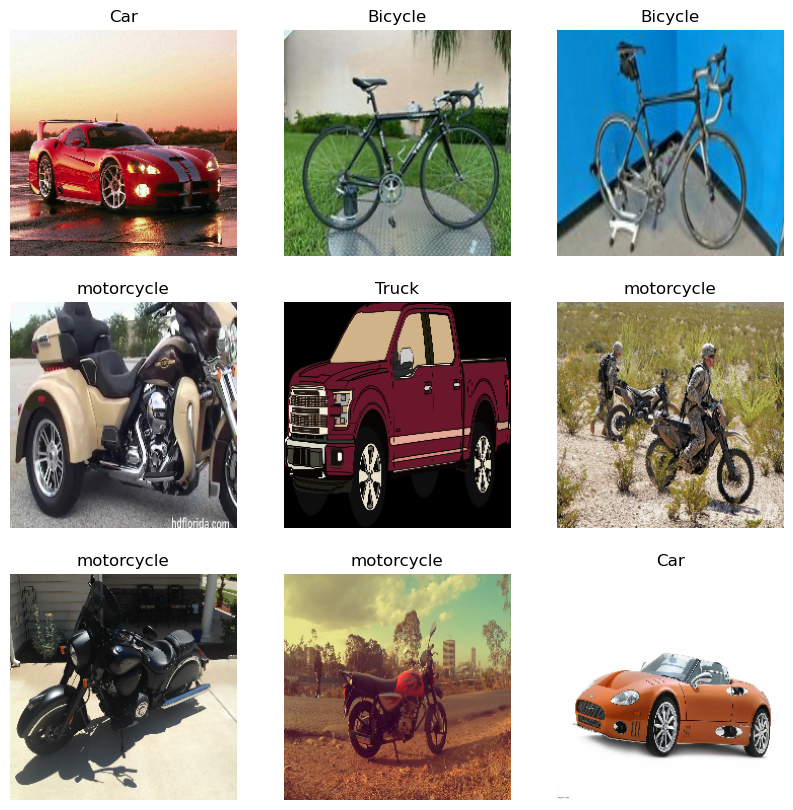

In [6]:
plt.figure(figsize=(10,10))


for images,labels in train_data.take(1):


    for i in range(9):


        plt.subplot(3,3,i+1)


        plt.imshow(
            images[i].numpy().astype("uint8")
        )


        plt.title(
            class_names[labels[i]]
        )


        plt.axis("off")


plt.show()

In [7]:
normalization=layers.Rescaling(1./255)



train_data=train_data.map(

lambda x,y:(normalization(x),y)

)



val_data=val_data.map(

lambda x,y:(normalization(x),y)

)

In [8]:
augmentation=models.Sequential([


layers.RandomFlip(
"horizontal"
),


layers.RandomRotation(
0.15
),


layers.RandomZoom(
0.2
),


layers.RandomContrast(
0.2
)


])

In [9]:
base_model=MobileNetV2(

weights="imagenet",

include_top=False,

input_shape=(224,224,3)

)

In [10]:
base_model.trainable=False

In [11]:
model=models.Sequential([augmentation,
                        base_model,
                        layers.GlobalAveragePooling2D(),
                        layers.Dense(256,activation="relu"),
                        layers.Dropout(0.3),
                        layers.Dense(len(class_names),
                        activation="softmax")
                        ])

In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
model.compile(

optimizer="adam",

loss="sparse_categorical_crossentropy",

metrics=["accuracy"]

)

In [14]:
early_stop=EarlyStopping(

monitor="val_loss",

patience=5,

restore_best_weights=True

)



checkpoint=ModelCheckpoint(

"best_vehicle_model.h5",

save_best_only=True

)

In [15]:
history=model.fit(

train_data,

validation_data=val_data,

epochs=30,

callbacks=[
early_stop,
checkpoint
]

)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.3988 - loss: 1.7235

20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 932ms/step - accuracy: 0.5781 - loss: 1.1797 - val_accuracy: 0.8813 - val_loss: 0.3382
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.8276 - loss: 0.4901

20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 834ms/step - accuracy: 0.8344 - loss: 0.4617 - val_accuracy: 0.9187 - val_loss: 0.2350
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - accuracy: 0.9068 - loss: 0.2644

20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 848ms/step - accuracy: 0.8984 - loss: 0.3072 - val_accuracy: 0.9500 - val_loss: 0.1845
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.9088 - loss: 0.2465

20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 807ms/step - accuracy: 0.9219 - loss: 0.2294 - val_accuracy: 0.9563 - val_loss: 0.1722
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 859ms/step - accuracy: 0.9359 - loss: 0.1883 - val_accuracy: 0.9187 - val_loss: 0.2096
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 861ms/step - accuracy: 0.9078 - loss: 0.2356 - val_accuracy: 0.9312 - val_loss: 0.1847
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 895ms/step - accuracy: 0.9469 - loss: 0.1500 - val_accuracy: 0.9438 - val_loss: 0.1905
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 814ms/step - accuracy: 0.9500 - loss: 0.1563 - val_accuracy: 0.9125 - val_loss: 0.2306
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 795ms/step - accuracy: 0.9359 - loss: 0.1882 - val_accuracy: 0.9062 - val_loss: 0.2241


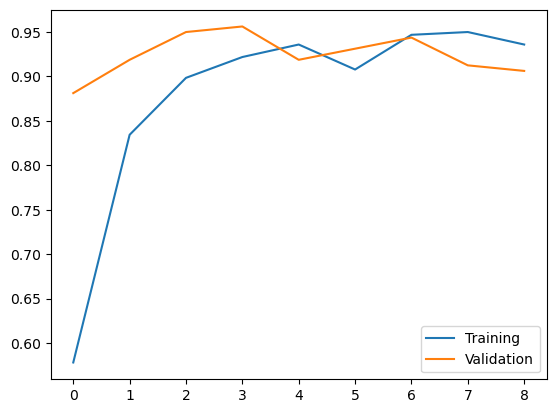

In [16]:
plt.plot(
history.history["accuracy"],
label="Training"
)


plt.plot(
history.history["val_accuracy"],
label="Validation"
)


plt.legend()

plt.show()

In [17]:
base_model.trainable=True

In [18]:
model.compile(

optimizer=tf.keras.optimizers.Adam(

learning_rate=0.00001

),

loss="sparse_categorical_crossentropy",

metrics=["accuracy"]

)

In [19]:
history2=model.fit(

train_data,

validation_data=val_data,

epochs=10

)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 145s 4s/step - accuracy: 0.7719 - loss: 0.6372 - val_accuracy: 0.9563 - val_loss: 0.1720
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 86s 4s/step - accuracy: 0.8406 - loss: 0.5007 - val_accuracy: 0.9563 - val_loss: 0.1683
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 86s 4s/step - accuracy: 0.8469 - loss: 0.4581 - val_accuracy: 0.9563 - val_loss: 0.1650
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 131s 4s/step - accuracy: 0.8781 - loss: 0.3857 - val_accuracy: 0.9625 - val_loss: 0.1642
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 78s 4s/step - accuracy: 0.8906 - loss: 0.3443 - val_accuracy: 0.9625 - val_loss: 0.1608
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step - accuracy: 0.8906 - loss: 0.3449 - val_accuracy: 0.9625 - val_loss: 0.1593
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 74s 4s/step - accuracy: 0.8906 - loss: 0.3259 - val_accuracy: 0.9625 - val_loss: 0.1588
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - accuracy: 0.9141 - loss: 0.2907 - val_accuracy: 0.9563 - val_los

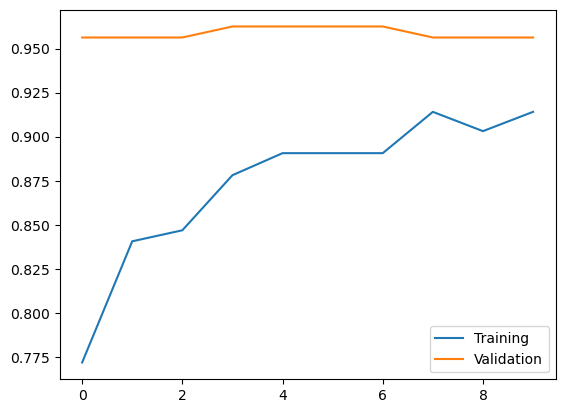

In [20]:
plt.plot(history2.history['accuracy'],label='Training')
plt.plot(history2.history['val_accuracy'],label='Validation')
plt.legend()
plt.show()

In [21]:
loss,accuracy=model.evaluate(val_data)
print("Accuracy:",accuracy*100)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 529ms/step - accuracy: 0.9563 - loss: 0.1524
Accuracy: 95.6250011920929


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 726ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step


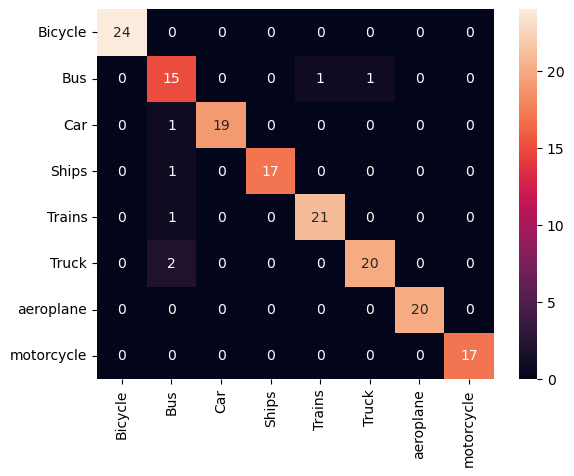

In [22]:
y_true=[]
y_pred=[]
for images,labels in val_data:
    pred=model.predict(images)
    pred_classes=np.argmax(pred,axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(pred_classes)
cm=confusion_matrix(y_true,y_pred)
sns.heatmap(cm,annot=True,xticklabels=class_names,yticklabels=class_names)
plt.show()

In [23]:
print(classification_report(y_true,y_pred,target_names=class_names))

              precision    recall  f1-score   support

     Bicycle       1.00      1.00      1.00        24
         Bus       0.75      0.88      0.81        17
         Car       1.00      0.95      0.97        20
       Ships       1.00      0.94      0.97        18
      Trains       0.95      0.95      0.95        22
       Truck       0.95      0.91      0.93        22
   aeroplane       1.00      1.00      1.00        20
  motorcycle       1.00      1.00      1.00        17

    accuracy                           0.96       160
   macro avg       0.96      0.96      0.96       160
weighted avg       0.96      0.96      0.96       160



In [24]:
def predict_vehicle(image_path):
    img=cv2.imread(image_path)
    # BGR to RGB
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img=cv2.resize(img,(224,224))
    img=img/255.0
    img=np.expand_dims(img,axis=0)
    prediction=model.predict(img)
    index=np.argmax(prediction)
    confidence=np.max(prediction)
    print("Vehicle:",class_names[index])
    print("Confidence:",confidence*100,"%")
predict_vehicle('test/bc.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Vehicle: Bicycle
Confidence: 99.97091 %
